# Exploration — LandCover (Occupation du sol)

Fichiers concernés :
- `data/EnvironmentalValues/LandCover/GLC25-PA-train-landcover.csv`
- `data/EnvironmentalValues/LandCover/GLC25-PA-test-landcover.csv`

Source : MODIS Terra+Aqua 500m. 13 colonnes `LandCover-1` à `LandCover-13` représentant différentes classifications (IGBP 17 classes, LCCS 43 classes, etc.).

Les colonnes correspondent probablement aux bandes successives du produit MODIS MCD12Q1 :
- Bands 1-3 : IGBP, UMD, LAI classification
- Bands 4-8 : LCCS layer1, layer2, layer3, confidence
- etc.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist

LC_DIR = '/data/challenge2026MIASHS/EnvironmentalValues/LandCover/'

train = pd.read_csv(LC_DIR + 'GLC25-PA-train-landcover.csv')
test  = pd.read_csv(LC_DIR + 'GLC25-PA-test-landcover.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
train.head()
test.head()

Train shape: (88987, 14)
Test  shape: (14829, 14)


,surveyId,LandCover-1,LandCover-2,LandCover-3,LandCover-4,LandCover-5,LandCover-6,LandCover-7,LandCover-8,LandCover-9,LandCover-10,LandCover-11,LandCover-12,LandCover-13
0,642,9,9,4,4,4,86,86,86,22,20,20,0,2
1,1792,10,10,1,6,6,87,87,87,31,30,30,2,2
2,3256,10,10,1,6,6,94,94,94,31,30,30,0,2
3,3855,10,10,1,6,6,94,94,94,31,30,30,0,2
4,4889,5,5,6,4,4,80,72,72,15,10,10,0,2


## 1. Valeurs manquantes

In [2]:
print('Valeurs manquantes TRAIN:')
m = train.isnull().sum()
print(m[m > 0] if m.sum() > 0 else 'Aucune')

print('\nValeurs manquantes TEST:')
m = test.isnull().sum()
print(m[m > 0] if m.sum() > 0 else 'Aucune')

Valeurs manquantes TRAIN:
Aucune

Valeurs manquantes TEST:
Aucune


## 2. Statistiques descriptives

In [3]:
lc_cols = [c for c in train.columns if c != 'surveyId']
print('Colonnes:', lc_cols)
train[lc_cols].describe().round(2)

Colonnes: ['LandCover-1', 'LandCover-2', 'LandCover-3', 'LandCover-4', 'LandCover-5', 'LandCover-6', 'LandCover-7', 'LandCover-8', 'LandCover-9', 'LandCover-10', 'LandCover-11', 'LandCover-12', 'LandCover-13']


,LandCover-1,LandCover-2,LandCover-3,LandCover-4,LandCover-5,LandCover-6,LandCover-7,LandCover-8,LandCover-9,LandCover-10,LandCover-11,LandCover-12,LandCover-13
count,88987.00,88987.00,88987.00,88987.00,88987.00,88987.00,88987.00,88987.00,88987.00,88987.00,88987.00,88987.00,88987.00
mean,10.19,9.46,3.48,3.96,4.31,89.11,87.48,89.11,22.75,22.44,21.66,0.59,1.95
std,3.36,3.35,2.29,2.04,2.44,9.44,13.25,9.72,7.58,10.15,9.56,1.65,0.22
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,9.00,9.00,1.00,2.00,2.00,85.00,83.00,84.00,21.00,20.00,20.00,0.00,2.00
50%,10.00,9.00,4.00,4.00,4.00,91.00,91.00,92.00,22.00,20.00,20.00,0.00,2.00
75%,12.00,12.00,4.00,6.00,7.00,96.00,96.00,97.00,31.00,30.00,30.00,0.00,2.00
max,17.00,15.00,10.00,8.00,11.00,99.00,99.00,99.00,43.00,40.00,51.00,9.00,2.00


## 3. Distribution des classes (LandCover-1 = IGBP)

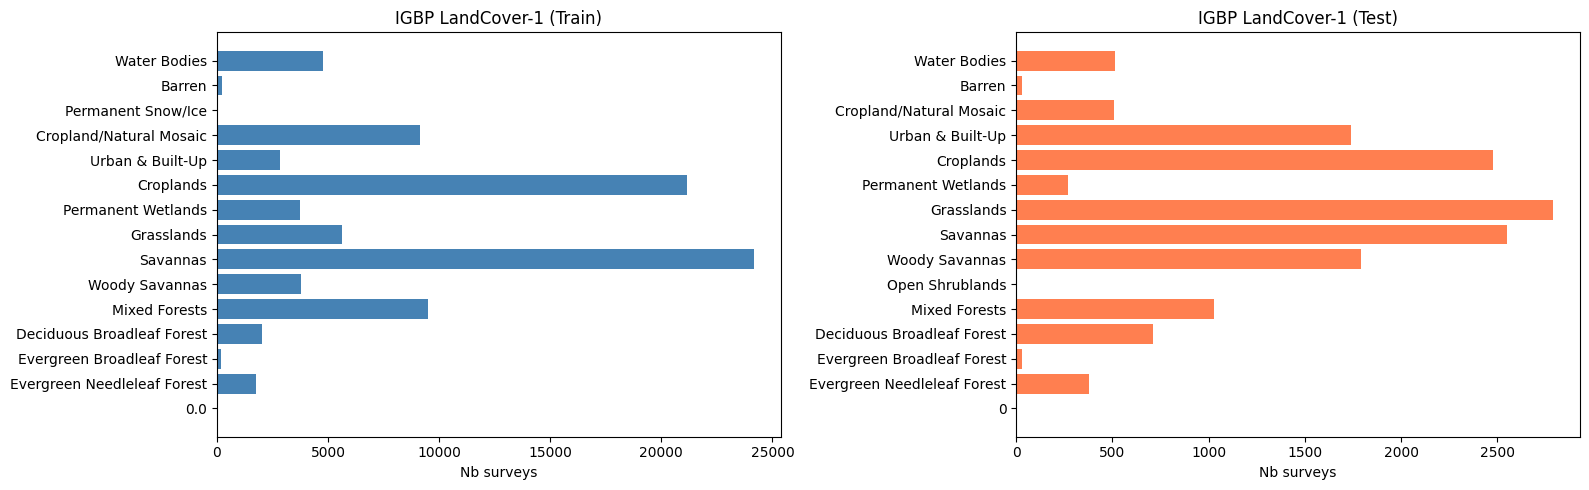

In [4]:
# IGBP class labels
igbp_labels = {
    1: 'Evergreen Needleleaf Forest',
    2: 'Evergreen Broadleaf Forest',
    3: 'Deciduous Needleleaf Forest',
    4: 'Deciduous Broadleaf Forest',
    5: 'Mixed Forests',
    6: 'Closed Shrublands',
    7: 'Open Shrublands',
    8: 'Woody Savannas',
    9: 'Savannas',
    10: 'Grasslands',
    11: 'Permanent Wetlands',
    12: 'Croplands',
    13: 'Urban & Built-Up',
    14: 'Cropland/Natural Mosaic',
    15: 'Permanent Snow/Ice',
    16: 'Barren',
    17: 'Water Bodies'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df, split in [(axes[0], train, 'Train'), (axes[1], test, 'Test')]:
    counts = df['LandCover-1'].value_counts().sort_index()
    labels = [igbp_labels.get(int(k), str(k)) for k in counts.index]
    ax.barh(labels, counts.values, color='steelblue' if split == 'Train' else 'coral')
    ax.set_title(f'IGBP LandCover-1 ({split})')
    ax.set_xlabel('Nb surveys')

plt.tight_layout()
plt.show()

## 4. Distribution de toutes les bandes

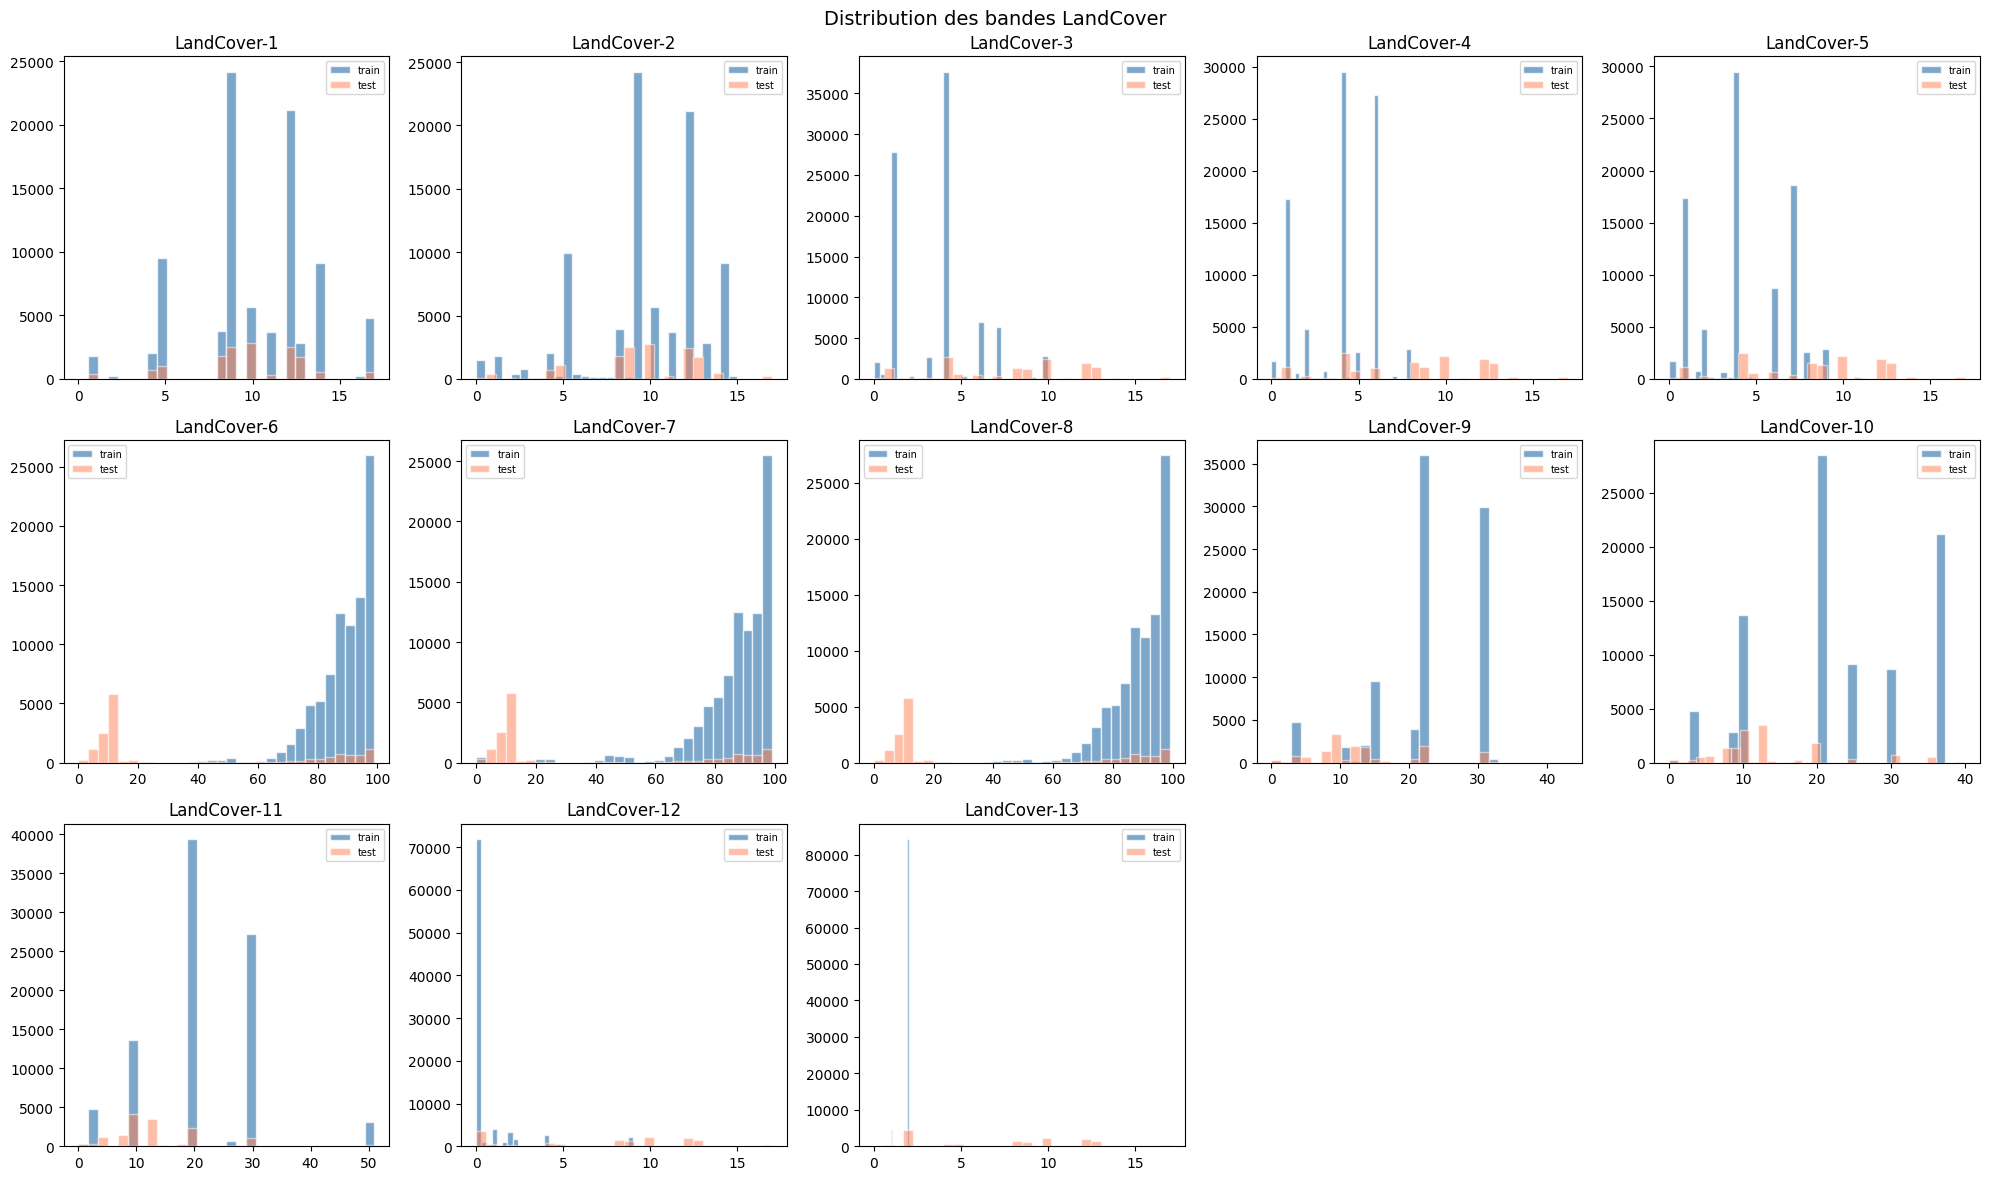

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(lc_cols):
    axes[i].hist(train[col].dropna(), bins=30, color='steelblue', alpha=0.7, label='train', edgecolor='white')
    axes[i].hist(test[col].dropna(), bins=30, color='coral', alpha=0.5, label='test', edgecolor='white')
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

# Supprimer les axes inutilisés
for j in range(len(lc_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution des bandes LandCover', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Matrice de corrélation

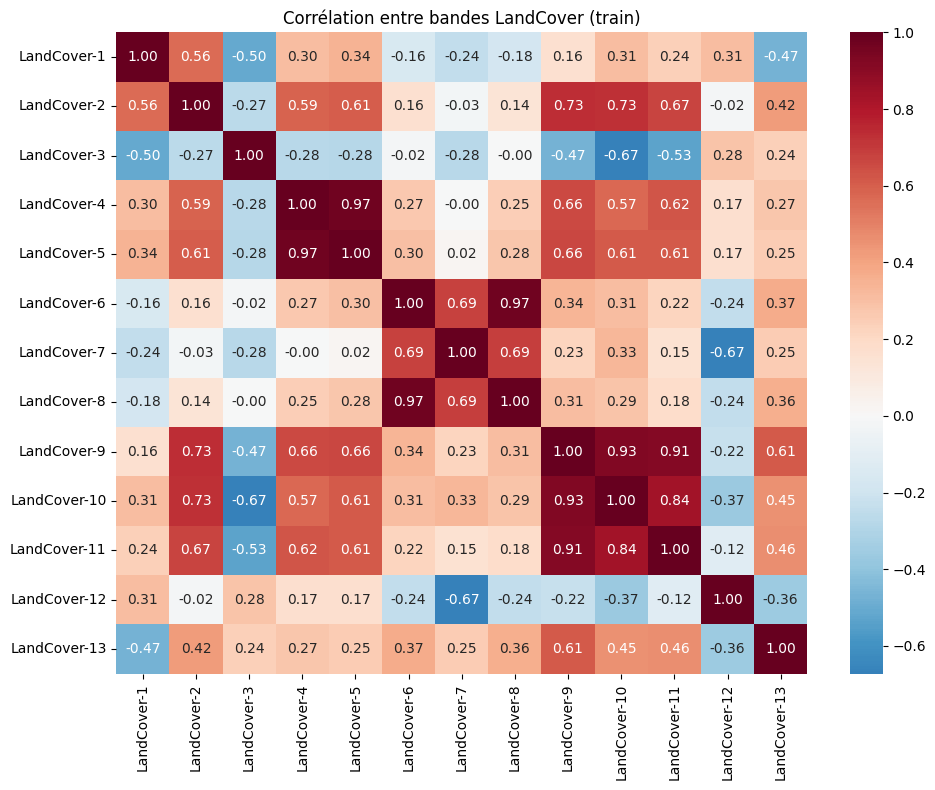

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(train[lc_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Corrélation entre bandes LandCover (train)')
plt.tight_layout()
plt.show()

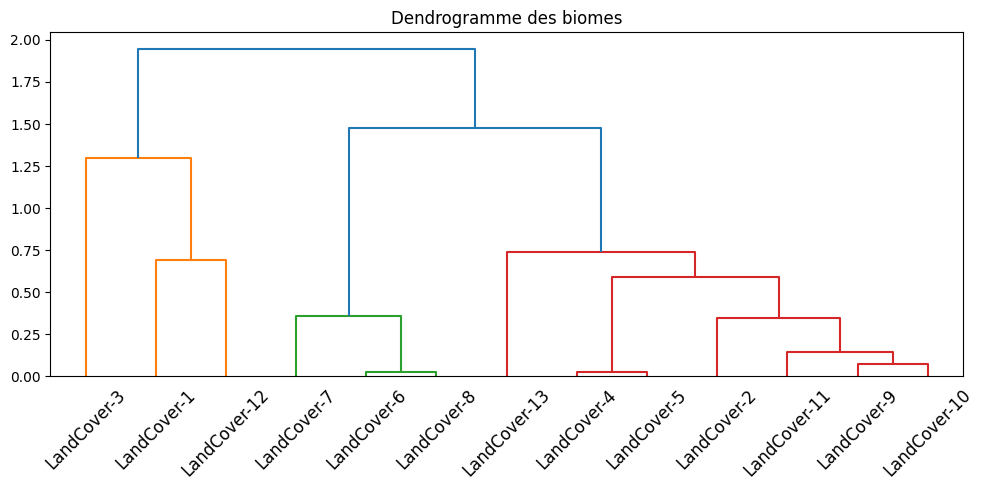

Mapping biomes → clusters:
  LandCover-1: Cluster 1
  LandCover-2: Cluster 5
  LandCover-3: Cluster 3
  LandCover-4: Cluster 5
  LandCover-5: Cluster 5
  LandCover-6: Cluster 4
  LandCover-7: Cluster 4
  LandCover-8: Cluster 4
  LandCover-9: Cluster 5
  LandCover-10: Cluster 5
  LandCover-11: Cluster 5
  LandCover-12: Cluster 2
  LandCover-13: Cluster 6

Train: (88987, 14) → (88987, 7)
Test:  (14829, 14)  → (14829, 7)


In [9]:
LC_COLS = [f'LandCover-{i}' for i in range(1, 14)]

# --- 1. Matrice de co-occurrence / corrélation entre biomes ---
# On transpose pour avoir les biomes en lignes et les observations en colonnes
biome_matrix = train[LC_COLS].T  # shape: (13, n_samples)

# Corrélation entre biomes (sur les observations)
corr_matrix = biome_matrix.corrwith  # alternative : np.corrcoef
corr_matrix = np.corrcoef(biome_matrix.values)  # shape (13, 13)

# Distance = 1 - corrélation (valeurs entre 0 et 2)
distance_matrix = 1 - corr_matrix
np.fill_diagonal(distance_matrix, 0)

# --- 2. Clustering hiérarchique ---
condensed_dist = pdist(biome_matrix.values, metric='correlation')
Z = linkage(condensed_dist, method='ward')

# Visualisation du dendrogramme pour choisir le seuil
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=LC_COLS, leaf_rotation=45)
plt.title("Dendrogramme des biomes")
plt.tight_layout()
plt.savefig("dendrogram_biomes.png", dpi=150)
plt.show()

# --- 3. Choix du nombre de clusters (ex: 5 groupes) ---
N_CLUSTERS = 6  # à ajuster selon le dendrogramme
labels = fcluster(Z, t=N_CLUSTERS, criterion='maxclust')

# Mapping biome → cluster
biome_to_cluster = dict(zip(LC_COLS, labels))
print("Mapping biomes → clusters:")
for biome, cluster in biome_to_cluster.items():
    print(f"  {biome}: Cluster {cluster}")

# --- 4. Création des nouvelles features agrégées ---
def aggregate_biomes(df, biome_to_cluster, n_clusters, agg='mean'):
    """Remplace les 13 colonnes par n_clusters colonnes agrégées."""
    new_df = df.copy()
    
    for c in range(1, n_clusters + 1):
        cols_in_cluster = [b for b, cl in biome_to_cluster.items() if cl == c]
        col_name = f'Biome_cluster_{c}'
        
        if agg == 'mean':
            new_df[col_name] = df[cols_in_cluster].mean(axis=1)
        elif agg == 'max':
            new_df[col_name] = df[cols_in_cluster].max(axis=1)
        elif agg == 'sum':
            new_df[col_name] = df[cols_in_cluster].sum(axis=1)
    
    # Supprimer les colonnes originales
    new_df = new_df.drop(columns=list(biome_to_cluster.keys()), errors='ignore')
    return new_df

train_clustered = aggregate_biomes(train, biome_to_cluster, N_CLUSTERS, agg='mean')
test_clustered  = aggregate_biomes(test,  biome_to_cluster, N_CLUSTERS, agg='mean')

print(f"\nTrain: {train.shape} → {train_clustered.shape}")
print(f"Test:  {test.shape}  → {test_clustered.shape}")